In [ ]:
import pandas as pd
import numpy as np
import os
import torch

from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, precision_score, recall_score, confusion_matrix, precision_recall_curve

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
os.chdir("/content/drive/MyDrive/3. Grad School/리스크 관리 경진대회")

#### 최종 설정

In [ ]:
data = pd.read_pickle("DATA/Health_Insurance_final.pkl")

In [ ]:
target = 'is_churn'

x_cols = [
    # 기본
    'premium', 'seniority_policy', 'type_policy_dg', 'type_product', 'new_business',
    'log_cost_claims_year', 'distribution_channel',
    # 나이 관련
    'age',
    # 성별 관련
    'gender',
    # 지역 관련
    'IICIMUN_capped', 'IICIPROV', 'C_C', 'C_H_num', 'C_GI', 'C_IE_T',
]

der_cols = [
    'missing_geo_cxt',       # 지역 결측 신호
    'high_loss',                  # 보험사 손해율
    'relative_poverty',        # 지역 내 상대적 빈곤
    'kr_premium_shock',   # 가격 인상 압박(비율 단위)
    'kr_economic_stress',  # 소득 대비 체감 부담
    # 'kr_retention_years',    # 장기 유지 혜택
    'kr_early_laps',             #신계약 위험 구간
    # 'kr_direct_channel',     # 가입 채널 영향
    'kr_medical_desert'     # 인프라 취약성
]

print(f"사용 변수 개수(기본) : {len(x_cols)}")
print(f"사용 변수 개수(파생) : {len(der_cols)}")
x_cols += der_cols
print(f"최종 변수 개수 : {len(x_cols)}개")

device = "cuda" if torch.cuda.is_available() else "cpu"

사용 변수 개수(기본) : 15
사용 변수 개수(파생) : 7
최종 변수 개수 : 22개


In [ ]:
### Encoding
cat_cols = ['type_policy_dg', 'type_product', 'new_business', 'distribution_channel', 'gender', 'C_C', 'kr_early_laps']

In [ ]:
import joblib
# XGBoost
model_data = joblib.load("Model/xgb_package2.pkl")
model = model_data['model']
fixed_params = model_data['fixed_params']
del fixed_params['early_stopping_rounds']
best_params = model_data['best_params']
threshold = model_data['threshold']

y_pred = joblib.load("Model/xgb_pred2.pkl")

In [ ]:
### train/test split
for col in cat_cols:
    data[col] = data[col].astype(str).astype('category')

train = data[data['period'].isin([2017, 2018])]
test = data[data['period'] == 2019]

x_train = train[x_cols]
y_train = train[target]
x_test = test[x_cols]
y_test = test[target]

#### 성능 평가

In [ ]:
final_params = {**best_params, **fixed_params}

# 모델 학습
model = XGBClassifier(**final_params, enable_categorical = True)
model.fit(x_train, y_train, verbose = False)

# 추론
y_prob = model.predict_proba(x_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

# 성능 확인
pr_auc = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("="*50)
print(f"[{model.__class__.__name__} 최종 성능 보고서]")
print("-"*50)
print(f"PR-AUC (기본 성능) : {pr_auc:.4f}")
print(f"ROC-AUC (기본 성능): {roc_auc:.4f}")
print("-"*50)
print(f"[최적 Threshold {threshold:.4f} 기준]")
print(f"F1-Score : {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
print("-"*50)
print("혼동 행렬(Confusion Matrix):")
print(f"TN: {cm[0][0]} | FP: {cm[0][1]}")
print(f"FN: {cm[1][0]} | TP: {cm[1][1]}")
print("="*50)

[XGBClassifier 최종 성능 보고서]
--------------------------------------------------
PR-AUC (기본 성능) : 0.3990
ROC-AUC (기본 성능): 0.7424
--------------------------------------------------
[최적 Threshold 0.5024 기준]
F1-Score : 0.4128 | Precision: 0.3381 | Recall: 0.5301
--------------------------------------------------
혼동 행렬(Confusion Matrix):
TN: 50815 | FP: 12657
FN: 5731 | TP: 6464


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [04:55:46] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


#### PDP

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.inspection import PartialDependenceDisplay, partial_dependence

In [ ]:
# SHAP 중요도 상위 10개 변수 고정 목록
top_features = [
    'seniority_policy',       # 1위: 보험 계약 유지 기간 (가장 압도적인 영향력)
    'log_cost_claims_year',   # 2위: 연간 청구 비용의 로그값
    'high_loss',              # 3위: 고액 손해/부실 여부
    'age',                    # 4위: 나이 (우리가 집중하고 있는 민감 변수!)
    'IICIPROV',               # 5위: 기관/지역 관련 식별 코드
    'premium',                # 6위: 보험료
    'type_policy_dg',         # 7위: 증권 유형 (범주형)
    'kr_premium_shock',       # 8위: 보험료 급등/충격 지수
    'new_business',           # 9위: 신규 계약 여부 (범주형)
    'C_IE_T'                  # 10위: 계약/고객 세부 유형 코드
]

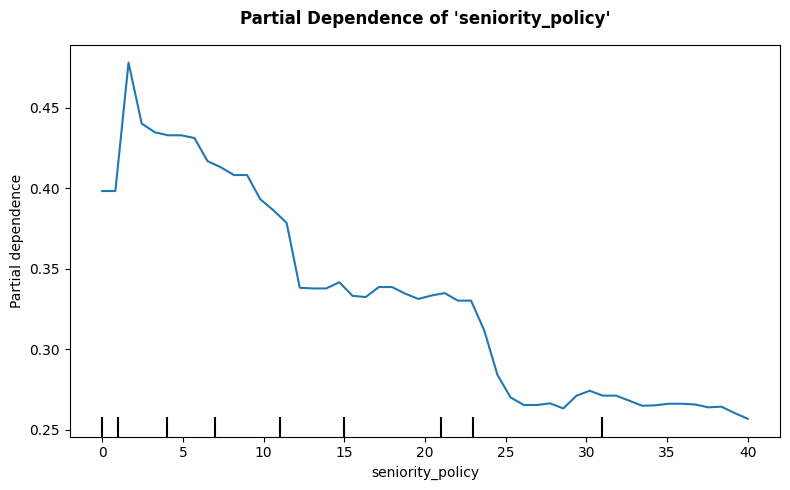

------------------------------------------------------------


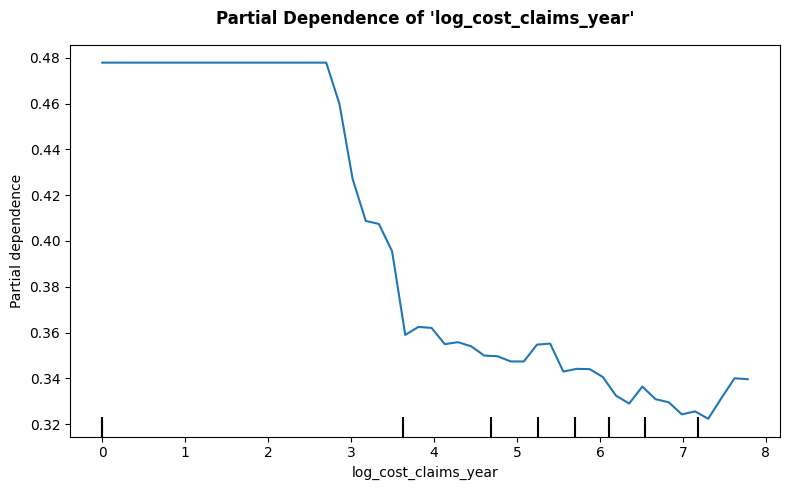

------------------------------------------------------------


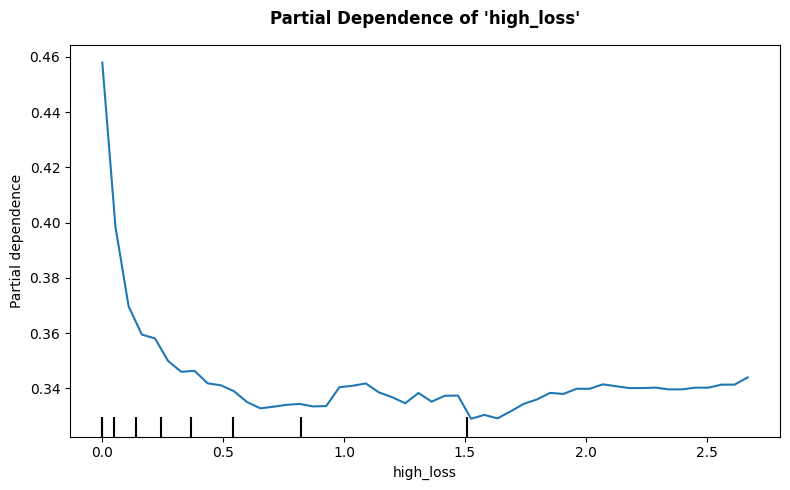

------------------------------------------------------------


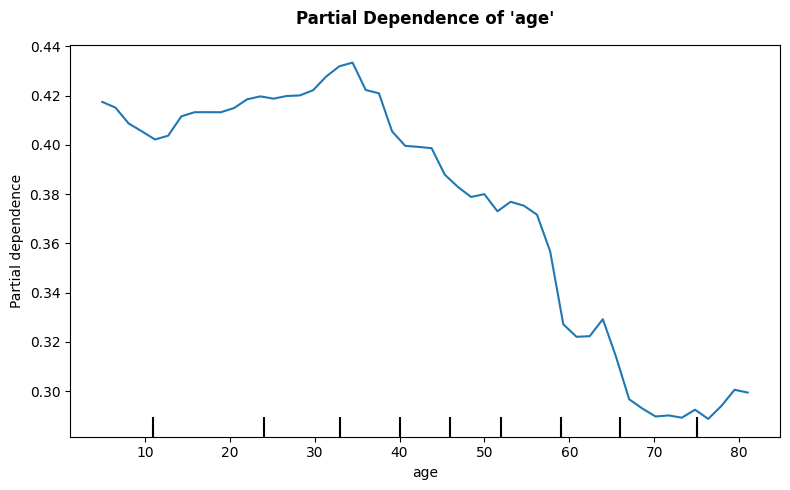

------------------------------------------------------------


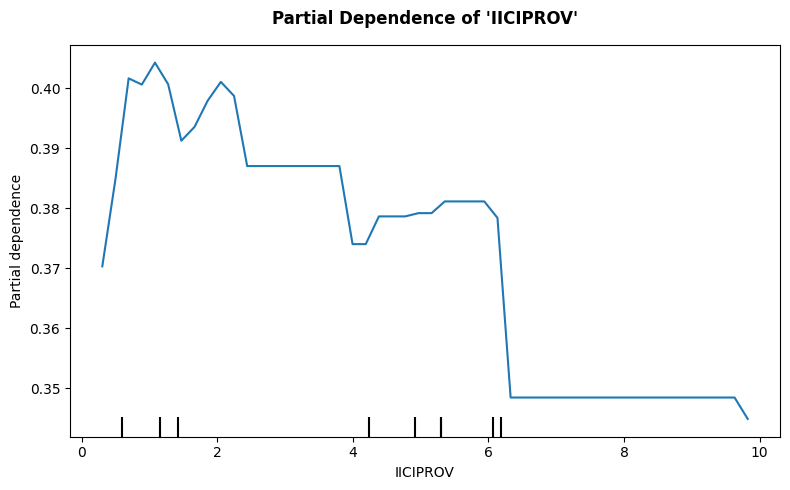

------------------------------------------------------------


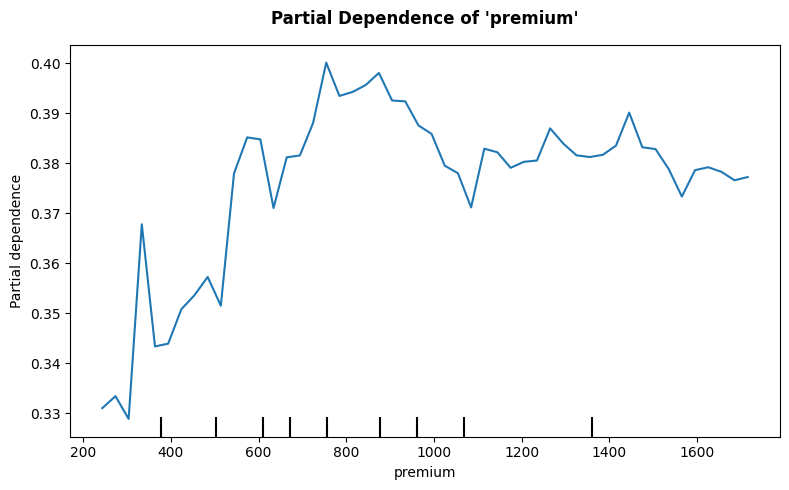

------------------------------------------------------------


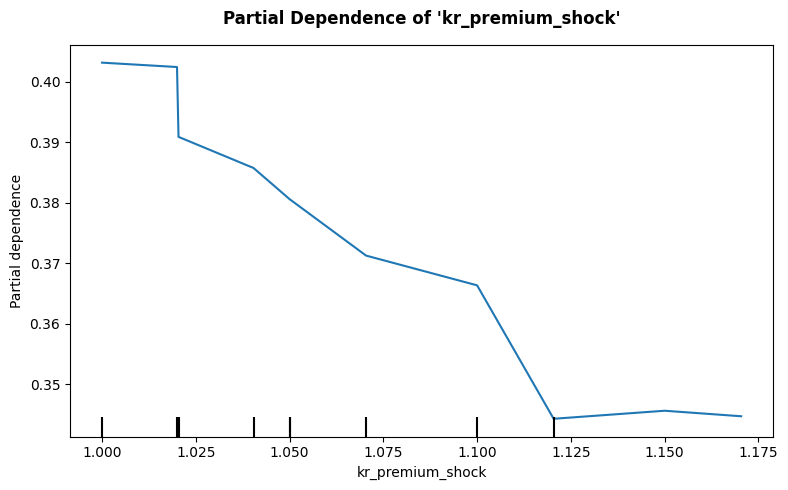

------------------------------------------------------------


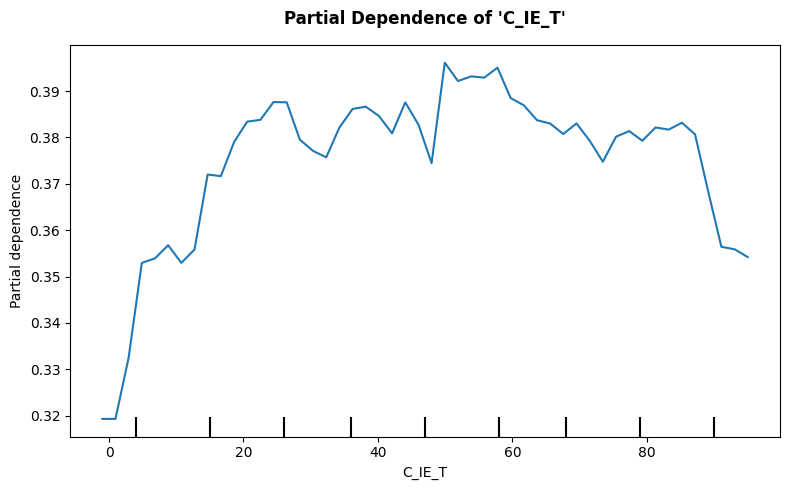

------------------------------------------------------------


In [ ]:
# ── 3. 수치형 feature만 개별 PDP (하나씩 따로 그리기) ──────────
num_features = [f for f in top_features if f not in cat_cols]

for feature in num_features:
    # 각 변수마다 독립된 도화지(Figure) 생성
    fig, ax = plt.subplots(figsize=(8, 5))

    PartialDependenceDisplay.from_estimator(
        model,
        x_train,
        features=[feature],  # 단일 변수만 리스트로 전달
        kind="average",
        grid_resolution=50,
        n_jobs=-1,
        ax=ax,
    )

    # 그래프별 타이틀 및 스타일 세부 조정
    ax.set_title(f"Partial Dependence of '{feature}'", fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel("Partial Dependence (Churn Probability)", fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()
    print("-" * 60)

개별 PDP를 그릴 범주형 변수 목록: ['type_policy_dg', 'new_business', 'gender']


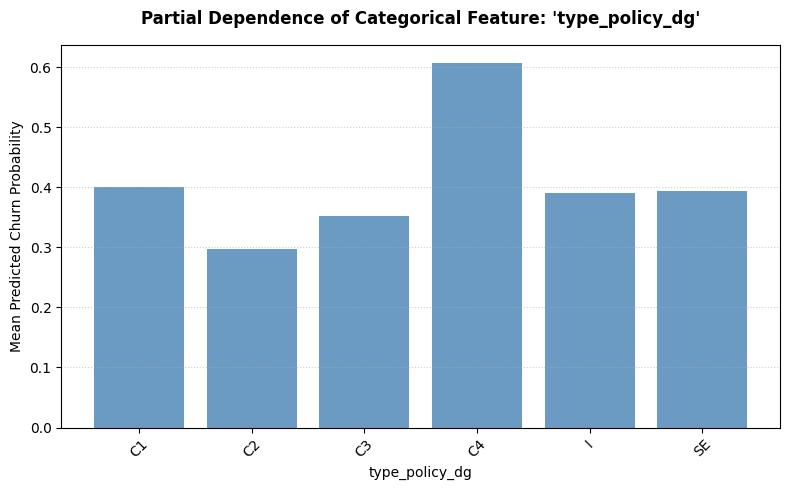

------------------------------------------------------------


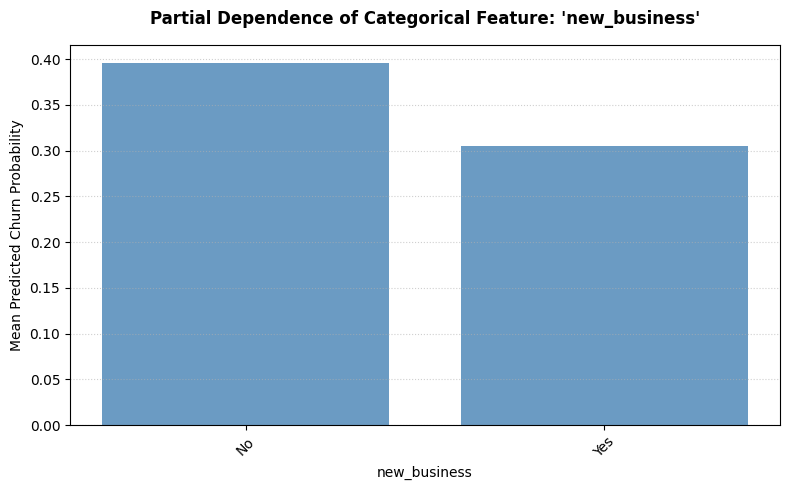

------------------------------------------------------------


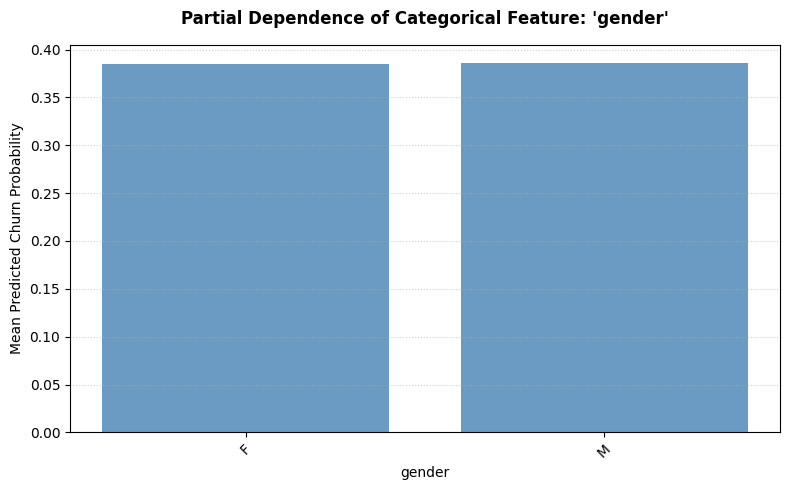

------------------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. 수동 계산 PDP 함수 (XGBoost 카테고리 에러 완벽 수정) ──
def plot_cat_pdp_manual(model, X, feat, original_series, ax):
    """각 카테고리 값으로 전체 데이터를 고정 후 평균 예측확률 계산 (ValueError 완벽 수정)"""
    # 1. 원본 데이터가 가진 카테고리 목록과 타입을 그대로 백업
    categories = original_series.cat.categories
    orig_dtype = original_series.dtype

    mean_preds = []
    for cat_val in categories:
        X_tmp = X.copy()

        # 2. 모든 행을 해당 카테고리 값으로 변경한 뒤, 원본의 고유 category dtype을 그대로 이식
        X_tmp[feat] = cat_val
        X_tmp[feat] = X_tmp[feat].astype(orig_dtype)

        # 3. 예측 평균값 계산
        mean_preds.append(model.predict_proba(X_tmp)[:, 1].mean())

    # 바 차트 시각화
    ax.bar(categories, mean_preds, color="steelblue", alpha=0.8)
    ax.tick_params(axis='x', rotation=45)

# ── 2. 분석할 범주형 변수 리스트 구성 ────────────────────────
# top_features에 포함된 범주형 변수들 추출
cat_top = [f for f in top_features if f in cat_cols]

# 중요도 순위에는 없었지만, 불공정성 검증을 위해 'gender' 강제 추가 (중복 방지)
if 'gender' not in cat_top and 'gender' in cat_cols:
    cat_top.append('gender')

print("개별 PDP를 그릴 범주형 변수 목록:", cat_top)

# ── 4. 루프를 돌며 하나씩 따로 그리기 ─────────────────────────
for feat in cat_top:
    # 각 변수마다 독립된 단일 도화지(Figure)와 축(ax) 생성
    fig, ax = plt.subplots(figsize=(8, 5))

    # 수동 계산 및 바 차트 시각화 함수 호출 (x_train 원본과 feat 전달)
    plot_cat_pdp_manual(model, x_train, feat, x_train[feat], ax)

    # 세부 스타일 보완
    ax.set_title(f"Partial Dependence of Categorical Feature: '{feat}'", fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel("Mean Predicted Churn Probability", fontsize=10)
    ax.grid(axis='y', linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show() # 하나의 그래프 출력을 완료하고 다음 루프로 이동
    print("-" * 60) # 그래프 간 구분을 위한 구분선

#### Feature Importance

In [ ]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_names = x_train.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

# 3. 중요도 순으로 정렬
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
print(feature_importance_df)

                 feature  importance
20         kr_early_laps    0.131193
1       seniority_policy    0.081879
4           new_business    0.080684
2         type_policy_dg    0.074308
5   log_cost_claims_year    0.058701
15       missing_geo_cxt    0.057240
16             high_loss    0.046224
11                   C_C    0.040541
10              IICIPROV    0.040022
7                    age    0.038061
6   distribution_channel    0.037417
3           type_product    0.036796
18      kr_premium_shock    0.033825
0                premium    0.031646
21     kr_medical_desert    0.031247
9         IICIMUN_capped    0.030228
17      relative_poverty    0.027781
19    kr_economic_stress    0.027700
14                C_IE_T    0.027220
13                  C_GI    0.026325
12               C_H_num    0.024932
8                 gender    0.016031


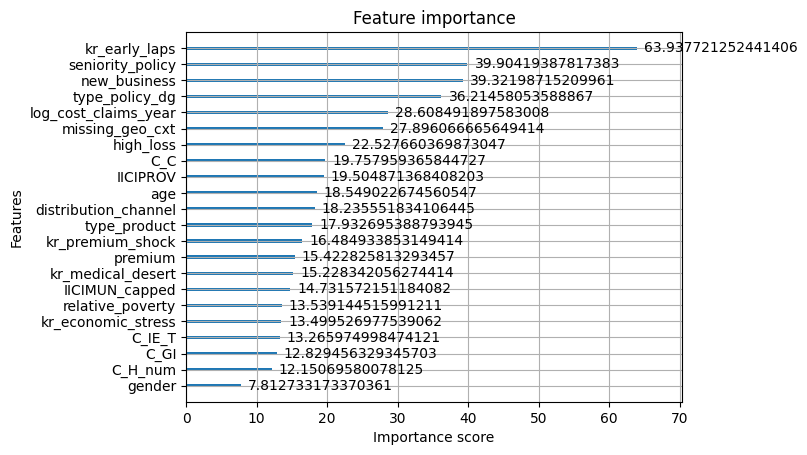

In [ ]:
from xgboost import plot_importance

# 중요도 시각화
plot_importance(model, importance_type = 'gain')
plt.show()